In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [87]:
df = pd.read_csv("data_for_preprocessing.csv")

In [88]:
df.head()

,Unnamed: 0,Text,Author
0,0,This study investigates the chemical compositi...,AI
1,1,This study explores the cultural history of oi...,AI
2,2,Isolation of human peripheral blood mononucle...,Human
3,3,Dynamic Bayesian Networks (DBNs) are probabil...,Human
4,4,"Within volleyball, performance analysis is em...",Human


In [89]:
df.tail()

,Unnamed: 0,Text,Author
6064,6064,Computational models serve as useful compleme...,Human
6065,6065,During transport and storage of drinking wate...,Human
6066,6066,The parameter values of neural networks will ...,Human
6067,6067,Crumb Rubber Modified Asphalt (CRMA) offers a...,Human
6068,6068,Generative AI for video is computationally exp...,AI


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6069 entries, 0 to 6068
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6069 non-null   int64 
 1   Text        6069 non-null   object
 2   Author      6069 non-null   object
dtypes: int64(1), object(2)
memory usage: 142.4+ KB


In [91]:
df.shape

(6069, 3)

In [92]:
df = df.drop(columns=["Unnamed: 0"])

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6069 entries, 0 to 6068
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    6069 non-null   object
 1   Author  6069 non-null   object
dtypes: object(2)
memory usage: 95.0+ KB


In [94]:
df.isnull().sum()

Text      0
Author    0
dtype: int64

In [95]:
df.duplicated().sum()

np.int64(0)

In [96]:
# convert Author to numeric

df["label"] = df["Author"].map({"Human":0,"AI":1})

In [97]:
# drop original aauthor column
df = df.drop(columns=["Author"])

In [98]:
#check class balance
df["label"].value_counts()

label
1    3069
0    3000
Name: count, dtype: int64

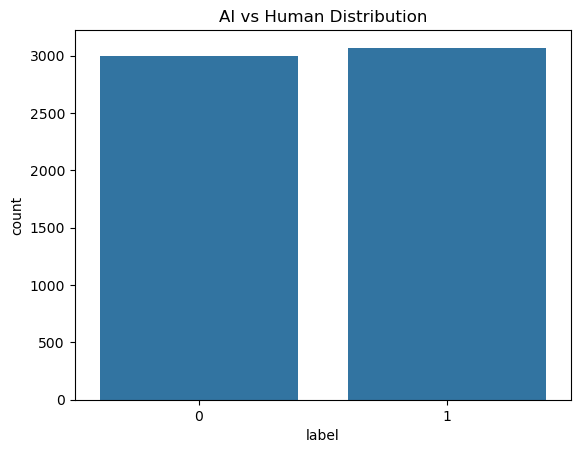

In [99]:
#plot distribution of classes

sns.countplot(x=df["label"])
plt.title("AI vs Human Distribution")
plt.show()

In [100]:
# character length
df["char_count"] = df["Text"].apply(len)

In [101]:
#word length
df["word_count"] = df["Text"].apply(lambda x: len(x.split()))

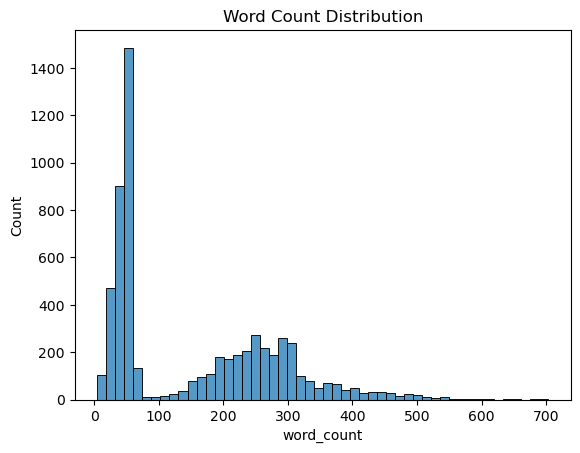

In [102]:
# word count distribution

sns.histplot(df["word_count"], bins=50)
plt.title("Word Count Distribution")
plt.show()

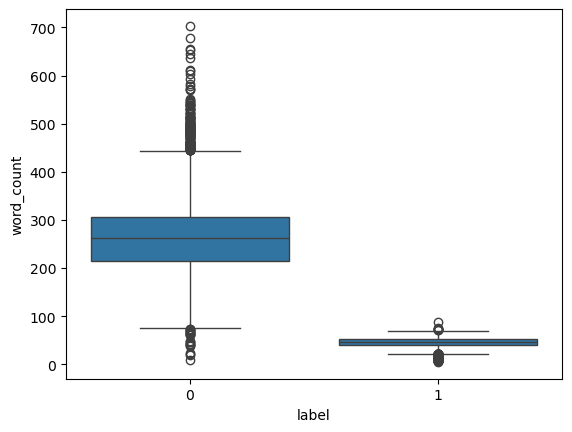

In [103]:
# Ai vs HUman word count distribution

sns.boxplot(x="label",y="word_count",data=df)
plt.show()

wordcloud Analysis

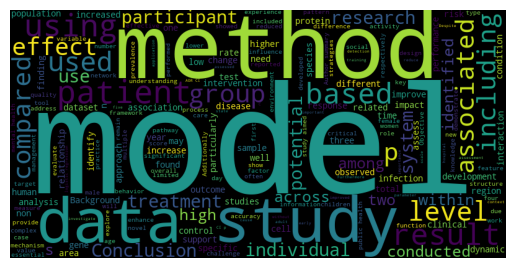

In [104]:
#humantext
from wordcloud import WordCloud

human_text = " ".join(df[df["label"]==0]["Text"])

wc = WordCloud(width=800,height=400).generate(human_text)

plt.imshow(wc)
plt.axis("off")
plt.show()

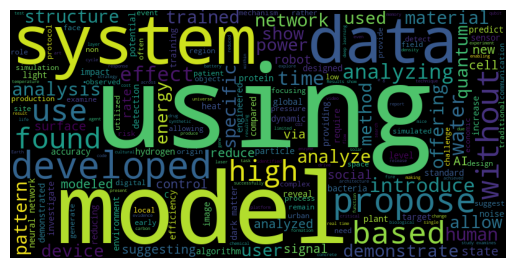

In [105]:
# AI text

ai_text = " ".join(df[df["label"]==1]["Text"])

wc = WordCloud(width=800,height=400).generate(ai_text)

plt.imshow(wc)
plt.axis("off")
plt.show()

when using NLTK for the first time. NLTK libraries are installed, but the datasets (corpora) like stopwords are not downloaded yet.

stopwords

wordnet

punkt

In [106]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [107]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [108]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

Steps:

lowercase

remove punctuation

remove stopwords

lemmatization

In [109]:
# text preprocessing

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z ]','',text)
    
    words = text.split()
    
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Example of transformation

before:

Artificial intelligence is changing industries rapidly!

after:

artificial intelligence changing industry rapidly

In [110]:
# feature engineering (TF-IDF)
# covert text to numbers

df["clean_text"] = df["Text"].apply(clean_text)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=2
)

X = vectorizer.fit_transform(df["clean_text"])
y = df["label"]

In [111]:
# dependent variable
y = df["label"]

In [112]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [113]:
# logistic regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [114]:
# naive bayes

from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [115]:
#random forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [116]:
#svm

from sklearn.svm import LinearSVC
svm = LinearSVC(C=1.5)
svm.fit(X_train,y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.5
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [117]:
# compare accuracy

from sklearn.metrics import accuracy_score

models = {
"Logistic":lr,
"Naive Bayes":nb,
"Random Forest":rf,
"SVM":svm
}

for name,model in models.items():

    pred = model.predict(X_test)

    acc = accuracy_score(y_test,pred)

    print(name,acc)

Logistic 0.9901153212520593
Naive Bayes 0.971169686985173
Random Forest 0.9950576606260296
SVM 0.9934102141680395


In [118]:
# save model
import pickle
pickle.dump(svm,open("model.pkl","wb"))
pickle.dump(vectorizer,open("vectorizer.pkl","wb"))

In [119]:
import pickle

# load model and vectorizer
model = pickle.load(open("model.pkl","rb"))
vectorizer = pickle.load(open("vectorizer.pkl","rb"))

# new text
text = "Artificial intelligence is transforming healthcare and education."

# convert text to vector
text_vector = vectorizer.transform([text])

# prediction
prediction = model.predict(text_vector)

# result
if prediction[0] == 1:
    print("AI Generated Text")
else:
    print("Human Written Text")

AI Generated Text
